In [1]:
import os
import math
import random
import csv
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import fidle

import neuralNetwork2 as nn
import mlx.core as mx

from skimage.morphology import disk 
from skimage. util import img_as_ubyte 
from skimage. filters import rank
from skimage import io, color, exposure, transform

In [25]:
scale = 1
output_dir = "datasets/gtsrb/"
datasets_dir = output_dir

# Création du dataset

In [3]:
df = pd.read_csv(f"{output_dir}archive/Test.csv")
display(df.head(10))

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png
5,52,56,5,5,47,51,38,Test/00005.png
6,147,130,12,12,135,119,18,Test/00006.png
7,32,33,5,5,26,28,12,Test/00007.png
8,45,50,6,5,40,45,25,Test/00008.png
9,81,86,7,7,74,79,35,Test/00009.png


In [4]:
def  read_csv_dataset(csv_file): 
    '''
    Reads traffic sign data from German Traffic Sign Recognition Benchmark dataset.
    Arguments:  
        csv filename :  Description file, Example /data/GTSRB/Train.csv
    Returns:
        x,y          :  np array of images, np array of corresponding labels
    '''

    path = os.path.dirname(csv_file)
    name = os.path.basename(csv_file)

    # ---- Read csv file
    #
    df = pd.read_csv(csv_file, header=0)
    
    # ---- Get filenames and ClassIds
    #
    filenames = df['Path'].to_list()
    y         = df['ClassId'].to_list()
    x         = []
    
    # ---- Read images
    #
    for filename in filenames:
        image=io.imread(f'{path}/{filename}')
        x.append(image)
        # fidle.utils.update_progress(name,len(x),len(filenames), verbosity=progress_verbosity)
    
    # ---- Return
    #
    return np.array(x,dtype=object),np.array(y)

In [16]:
chrono=fidle.Chrono()

chrono.start()

# ---- Read datasets

(x_train,y_train) = read_csv_dataset(f'{datasets_dir}/archive/Train.csv')
(x_test ,y_test)  = read_csv_dataset(f'{datasets_dir}/archive/Test.csv')
(x_meta ,y_meta)  = read_csv_dataset(f'{datasets_dir}/archive/Meta.csv')
    
# ---- Shuffle train set

x_train, y_train = fidle.utils.shuffle_np_dataset(x_train, y_train)

# ---- Sort Meta

combined = list(zip(x_meta,y_meta))
combined.sort(key=lambda x: x[1])
x_meta,y_meta = zip(*combined)

chrono.show()

Datasets have been shuffled.
Duration :  23.04 seconds


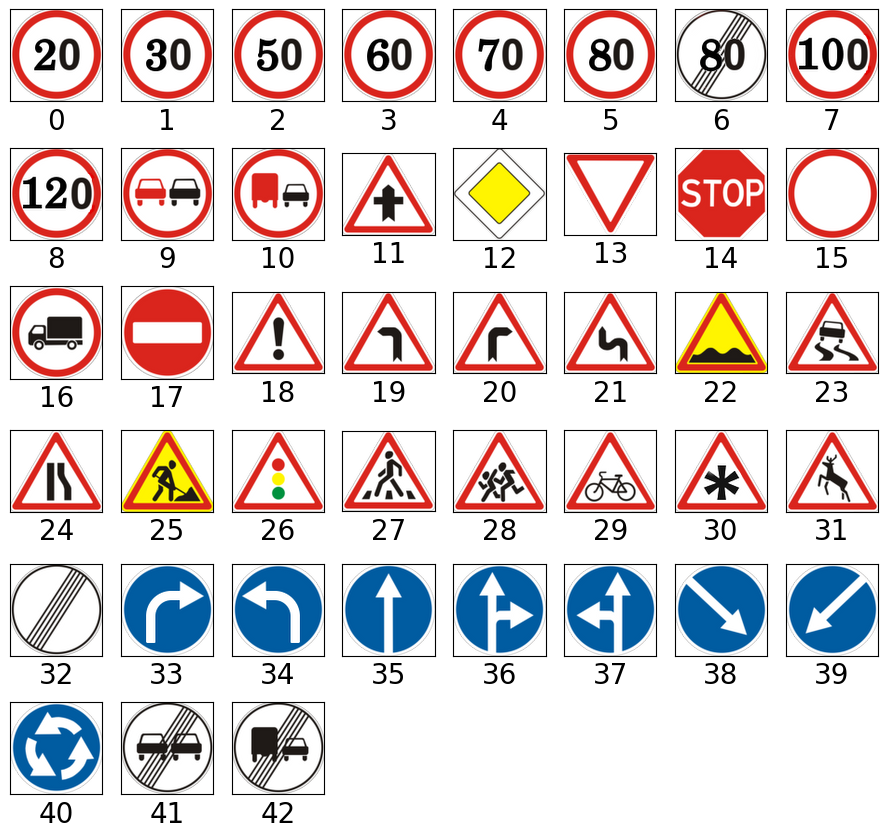

In [17]:
fidle.scrawler.images( x_meta,y_meta, range(43), columns=8, x_size=1.4, y_size=1.4, 
                       colorbar=False, y_pred=None, cm='binary', save_as='06-meta-signs')

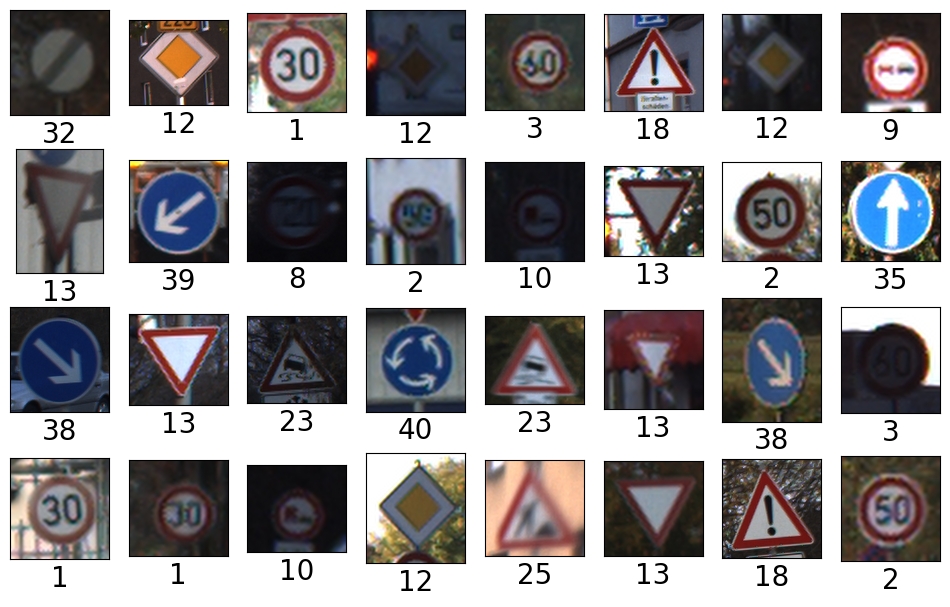

In [18]:
# ---- Get and show few images

samples = [ random.randint(0,len(x_train)-1) for i in range(32)]
fidle.scrawler.images( x_train,y_train, samples, columns=8, x_size=1.5, y_size=1.5, 
                       colorbar=False, y_pred=None, cm='binary', save_as='07-real-signs')

In [7]:
def images_enhancement(images, width=25, height=25, proc='RGB'):
    '''
    Resize and convert images - doesn't change originals.
    input images must be RGBA or RGB.
    Note : all outputs are fixed size numpy array of float32
    args:
        images :         images list
        width,height :   new images size (25,25)
        mode :           RGB | RGB-HE | L | L-HE | L-LHE | L-CLAHE
    return:
        numpy array of enhanced images
    '''
    lz={ 'RGB':3, 'RGB-HE':3, 'L':1, 'L-HE':1, 'L-LHE':1, 'L-CLAHE':1}[proc]
    
    out=[]
    for img in images:
        
        # ---- if RGBA, convert to RGB
        if img.shape[2]==4:
            img=color.rgba2rgb(img)
            
        # ---- Resize
        img = transform.resize(img, (width,height))

        # ---- RGB / Histogram Equalization
        if proc=='RGB-HE':
            hsv = color.rgb2hsv(img.reshape(width,height,3))
            hsv[:, :, 2] = exposure.equalize_hist(hsv[:, :, 2])
            img = color.hsv2rgb(hsv)
        
        # ---- Grayscale
        if proc=='L':
            img=color.rgb2gray(img)
            
        # ---- Grayscale / Histogram Equalization
        if proc=='L-HE':
            img=color.rgb2gray(img)
            img=exposure.equalize_hist(img)
            
        # ---- Grayscale / Local Histogram Equalization
        if proc=='L-LHE':        
            img=color.rgb2gray(img)
            img = img_as_ubyte(img)
            img=rank.equalize(img, disk(10))/255.
        
        # ---- Grayscale / Contrast Limited Adaptive Histogram Equalization (CLAHE)
        if proc=='L-CLAHE':
            img=color.rgb2gray(img)
            img=exposure.equalize_adapthist(img)
            
        # ---- Add image in list of list
        out.append(img)
        fidle.utils.update_progress('Enhancement: ',len(out),len(images))

    # ---- Reshape images
    #     (-1, width,height,1) for L
    #     (-1, width,height,3) for RGB
    #
    out = np.array(out,dtype='float32')
    out = out.reshape(-1,width,height,lz)
    return out

17621
Enhancement:     [################] 100.0% of 16
Enhancement:     [################] 100.0% of 16
Enhancement:     [################] 100.0% of 16
Enhancement:     [################] 100.0% of 16
Enhancement:     [################] 100.0% of 16
Enhancement:     [################] 100.0% of 16


<br>**EXPECTED**

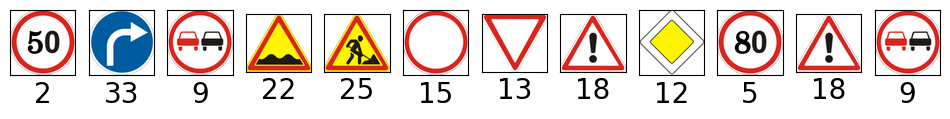

<br>**ORIGINAL**

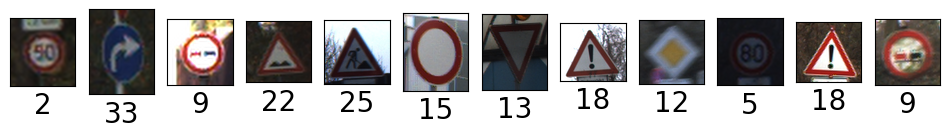

<br>**ENHANCED**

dataset : RGB  min,max=[0.044,1.000]  shape=(16, 25, 25, 3)


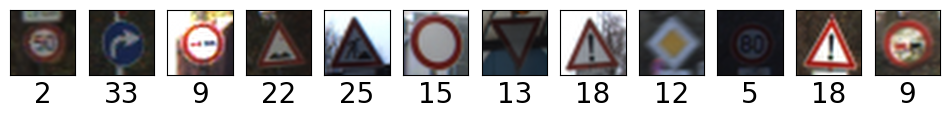

dataset : RGB-HE  min,max=[0.001,1.000]  shape=(16, 25, 25, 3)


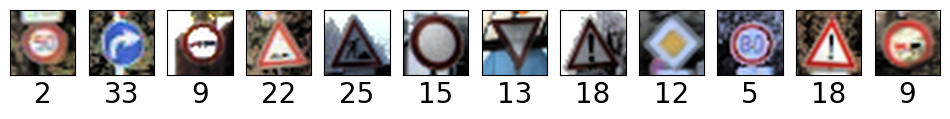

dataset : L  min,max=[0.054,1.000]  shape=(16, 25, 25, 1)


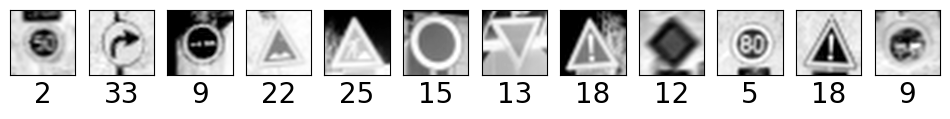

dataset : L-HE  min,max=[0.002,1.000]  shape=(16, 25, 25, 1)


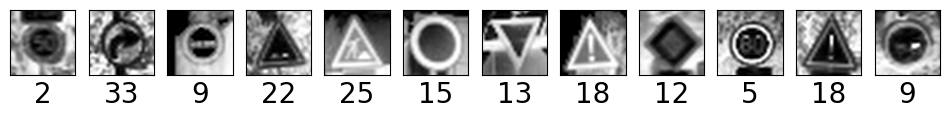

dataset : L-LHE  min,max=[0.000,1.000]  shape=(16, 25, 25, 1)


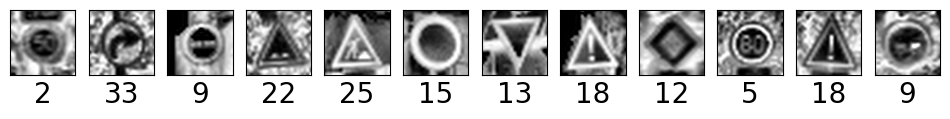

dataset : L-CLAHE  min,max=[0.000,1.000]  shape=(16, 25, 25, 1)


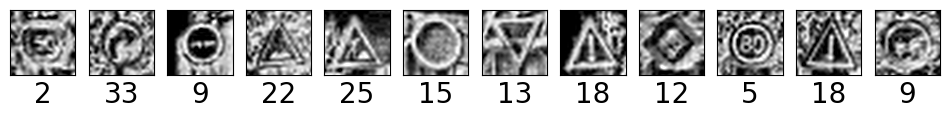

In [19]:
i=random.randint(0,len(x_train)-16)
print(i)
x_samples = x_train[i:i+16]
y_samples = y_train[i:i+16]

datasets  = {}

datasets['RGB']      = images_enhancement( x_samples, width=25, height=25, proc='RGB'  )
datasets['RGB-HE']   = images_enhancement( x_samples, width=25, height=25, proc='RGB-HE'  )
datasets['L']        = images_enhancement( x_samples, width=25, height=25, proc='L'  )
datasets['L-HE']     = images_enhancement( x_samples, width=25, height=25, proc='L-HE'  )
datasets['L-LHE']    = images_enhancement( x_samples, width=25, height=25, proc='L-LHE'  )
datasets['L-CLAHE']  = images_enhancement( x_samples, width=25, height=25, proc='L-CLAHE'  )

fidle.utils.subtitle('EXPECTED')
x_expected=[ x_meta[i] for i in y_samples]
fidle.scrawler.images(x_expected, y_samples, range(12), columns=12, x_size=1, y_size=1,
                colorbar=False, y_pred=None, cm='binary', save_as='08-expected')

fidle.utils.subtitle('ORIGINAL')
fidle.scrawler.images(x_samples,  y_samples, range(12), columns=12, x_size=1, y_size=1, 
                colorbar=False, y_pred=None, cm='binary', save_as='09-original')

fidle.utils.subtitle('ENHANCED')
n=10
for k,d in datasets.items():
    print("dataset : {}  min,max=[{:.3f},{:.3f}]  shape={}".format(k,d.min(),d.max(), d.shape))
    fidle.scrawler.images(d, y_samples, range(12), columns=12, x_size=1, y_size=1, 
                    colorbar=False, y_pred=None, cm='binary', save_as=f'{n}-enhanced-{k}')
    n+=1

In [21]:
def save_h5_dataset(x_train, y_train, x_test, y_test, x_meta,y_meta, filename):
        
    # ---- Create h5 file
    with h5py.File(filename, "w") as f:
        f.create_dataset("x_train", data=x_train)
        f.create_dataset("y_train", data=y_train)
        f.create_dataset("x_test",  data=x_test)
        f.create_dataset("y_test",  data=y_test)
        f.create_dataset("x_meta",  data=x_meta)
        f.create_dataset("y_meta",  data=y_meta)
        
    # ---- done
    size=os.path.getsize(filename)/(1024*1024)
    print('Dataset : {:24s}  shape : {:22s} size : {:6.1f} Mo   (saved)'.format(filename, str(x_train.shape),size))

In [ ]:
chrono=fidle.Chrono()

# ---- Size and processings
#
all_size= [24, 48]
all_proc=['RGB', 'RGB-HE', 'L', 'L-LHE']

# ---- Do it
#
chrono.start()

n_train = int( len(x_train)*scale )
n_test  = int( len(x_test)*scale )

fidle.utils.subtitle('Parameters :')
print(f'Scale is : {scale}')
print(f'x_train length is : {n_train}')
print(f'x_test  length is : {n_test}')
print(f'output dir is     : {output_dir}\n')

fidle.utils.subtitle('Running...')

fidle.utils.mkdir(output_dir)

for s in all_size:
    for m in all_proc:
        # ---- A nice dataset name
        filename = f'{output_dir}/set-{s}x{s}-{m}-{scale}.h5'
        fidle.utils.subtitle(f'Dataset : {filename}')
        
        # ---- Enhancement
        #      Note : x_train is a numpy array of python objects (images with <> sizes)
        #             but images_enhancement() return a real array of float64 numpy (images with same size)
        #             so, we can save it in nice h5 files
        #
        x_train_new = images_enhancement( x_train[:n_train], width=s, height=s, proc=m )
        x_test_new  = images_enhancement( x_test[:n_test],   width=s, height=s, proc=m )
        x_meta_new  = images_enhancement( x_meta,            width=s, height=s, proc='RGB' )
        
        # ---- Save
        save_h5_dataset( x_train_new, y_train[:n_train], x_test_new, y_test[:n_test], x_meta_new,y_meta, filename)

x_train_new,x_test_new=0,0

print('\nDone.')
chrono.show()

<br>**Parameters :**

Scale is : 1
x_train length is : 39209
x_test  length is : 12630
output dir is     : datasets/gtsrb/



<br>**Running...**

<br>**Dataset : datasets/gtsrb//set-24x24-RGB-1.h5**

Enhancement:     [########################################] 100.0% of 39209
Enhancement:     [########################################] 100.0% of 12630
Enhancement:     [########################################] 100.0% of 43
Dataset : datasets/gtsrb//set-24x24-RGB-1.h5  shape : (39209, 24, 24, 3)     size :  342.4 Mo   (saved)


...

Enhancement:     [########################################] 100.0% of 39209
Enhancement:     [########################################] 100.0% of 12630
Enhancement:     [########################################] 100.0% of 43
Dataset : datasets/gtsrb//set-24x24-L-LHE-1.h5  shape : (39209, 24, 24, 1)     size :  114.6 Mo   (saved)


<br>**Dataset : datasets/gtsrb//set-48x48-RGB-1.h5**

Enhancement:     [########################################] 100.0% of 39209
Enhancement:     [########################################] 100.0% of 12630
Enhancement:     [########################################] 100.0% of 43
Dataset : datasets/gtsrb//set-48x48-RGB-1.h5  shape : (39209, 48, 48, 3)     size : 1368.4 Mo   (saved)


<br>**Dataset : datasets/gtsrb//set-48x48-RGB-HE-1.h5**

Enhancement:     [########################################] 100.0% of 39209


# Réseau et CNN

In [4]:
dataset_name  = 'set-24x24-L'
batch_size    = 64
epochs        = 5
scale         = 1
fit_verbosity = 1

In [5]:
def read_dataset(output_dir, dataset_name, scale=1):
    '''
    Reads h5 dataset
    Args:
        filename     : datasets filename
        dataset_name : dataset name, without .h5
    Returns:    
        x_train,y_train, x_test,y_test data, x_meta,y_meta
    '''

    # ---- Read dataset
    #
    chrono=fidle.Chrono()
    chrono.start()
    filename = f'{output_dir}/{dataset_name}.h5'
    with  h5py.File(filename,'r') as f:
        x_train = f['x_train'][:]
        y_train = f['y_train'][:]
        x_test  = f['x_test'][:]
        y_test  = f['y_test'][:]
        x_meta  = f['x_meta'][:]
        y_meta  = f['y_meta'][:]

    # ---- Rescale 
    #
    print('Original shape  :', x_train.shape, y_train.shape)
    x_train,y_train, x_test,y_test = fidle.utils.rescale_dataset(x_train,y_train,x_test,y_test, scale=scale)
    print('Rescaled shape  :', x_train.shape, y_train.shape)

    # ---- Shuffle
    #
    x_train,y_train=fidle.utils.shuffle_np_dataset(x_train,y_train)

    # ---- done
    #
    duration = chrono.get_delay()
    size     = fidle.utils.hsize(os.path.getsize(filename))
    print(f'\nDataset "{dataset_name}" is loaded and shuffled. ({size} in {duration})')
    return x_train,y_train, x_test,y_test, x_meta,y_meta

In [6]:
# ---- Read dataset
#
x_train,y_train,x_test,y_test, x_meta,y_meta = read_dataset(output_dir, dataset_name, scale)

Original shape  : (3920, 24, 24, 1) (3920,)
Datasets have been resized with a factor  1
Rescaled shape  : (3920, 24, 24, 1) (3920,)
Datasets have been shuffled.

Dataset "set-24x24-L" is loaded and shuffled. (11.7 Mo in 0:00:00)


In [7]:
train_X, test_X = mx.array(x_train), mx.array(x_test)
train_X = train_X / 255.0
test_X = test_X / 255.0

In [8]:
train_Y = [nn.zeros_hot(43, x) for x in y_train]
test_Y = [nn.zeros_hot(43, x) for x in y_test]


x_train :  (3920, 24, 24, 1)
y_train :  (3920,)
x_test  :  (1263, 24, 24, 1)
y_test  :  (1263,)


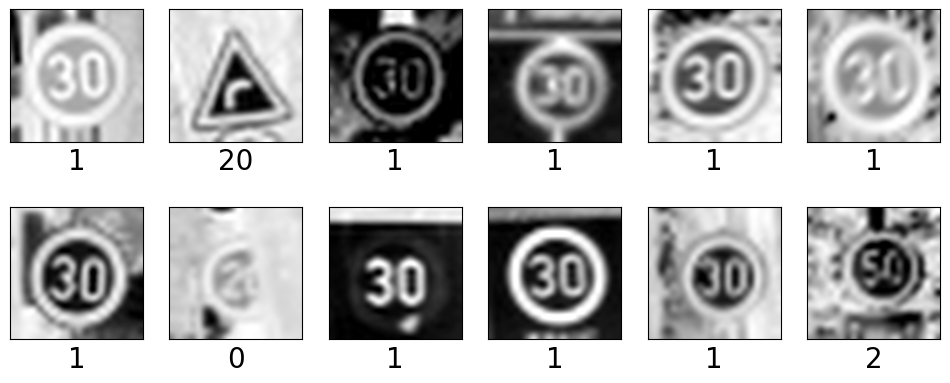

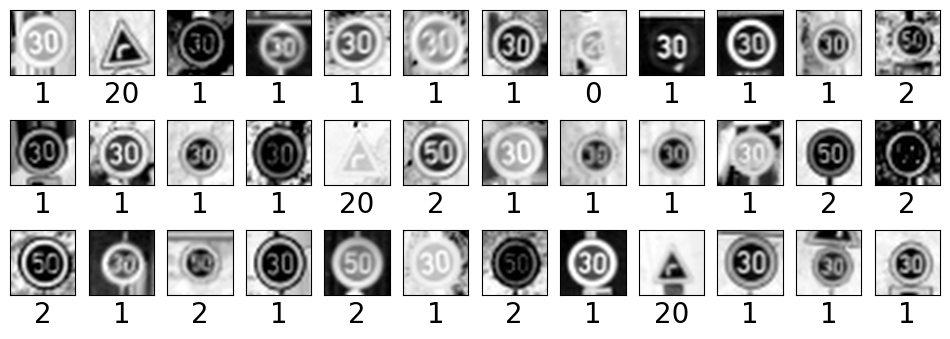

In [50]:
print("x_train : ", x_train.shape)
print("y_train : ", y_train.shape)
print("x_test  : ", x_test.shape)
print("y_test  : ", y_test.shape)

fidle.scrawler.images(x_train, y_train, range(12), columns=6,  x_size=2, y_size=2, save_as='01-dataset-medium')
fidle.scrawler.images(x_train, y_train, range(36), columns=12, x_size=1, y_size=1, save_as='02-dataset-small')